# Detecting for Structural Breaks in a Financial Time Series Data

# By: Samuel Reano

This financial econometrics project showcases the Bai-Perron test which is used for detecting a structural break date of the regime shift (Trump's global tariffs 2025-2026) in a financial time series data.


## A Brief Explanation of the Bai-Perron test

The Bai-Perron test answers the question *"how many structural breaks are there, and where are they?* This test uses a dynamic programming algorithm that computes the optimal partition in a number of operations proportionalto the square of the sample size, no matter how many breaks are allowed, by storing the best segmentation of every sub-sample and reusing it. The selection criterion is global: among all admissible partitions, choose the break dates that minimize the total sum of squared residuals across all segments.

## Extracting the Financial Time Series Data and Implementing the Bai-Perron Test

Suppose we have a portfolio of five tech stocks: Apple, HP, Dell, Nvidia, and AMD. The timeline of the data starts at April 10, 2024 and ends at April 8, 2026. We chose this timeline because the economists at TD Bank Group reported two dates that could be considered as an actual structural break date: April 5, 2025 and April 9, 2025 (https://economics.td.com/ca-trump-reciprocal-tariffs-2025). The reason for listing both dates in the report is that the first date is when the United States imposed a 10% tariff on all countries whereas the second date is when the United States imposed higher tariff rates on countries with the largest trade deficits.

Since the Bai-Perron test is designed for detecting multiple structural breaks within a time series, the maximum allowed breaks is 3 to avoid over-fitting and that it is economically rare to observe more than two or three distinct structural regime shifts in daily portfolio losses over 500 trading days. Due to this, the trimming parameter is set to 0.20. We chose the 99% confidence interval for a much wider, more conservative data range with higher certainty. The specification of the Bai-Perron model in the following chunk of Python code evaluates a mean-shift because Trump's global tariffs (2025-2026) can be viewed as a level break. In the following Python code, we used a 4-day moving average of our portfolio because daily stock price changes contain immense high-frequency noise.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

# 1. Define Parameters and Timeframe
tickers = ['AAPL', 'HPQ', 'DELL', 'NVDA', 'AMD']
start_date = '2024-04-09'
end_date = '2026-04-09'

initial_investment = 100000
M = 5

# 2. Download and Clean Data
# We use the 'Close' price to represent the daily price of the stock
print(f"Downloading data from {start_date} to {end_date}...")
data = yf.download(tickers, start=start_date, end=end_date)['Close']

# Clean the data by dropping any rows with missing values (e.g., market holidays)
data = data.dropna()

# 3. Calculate Initial Shares per Stock
# P_{A,0} is the first available price for each stock in our timeframe
P_0 = data.iloc[0]

# Shares_A = (I/M) / P_{A,0}
shares = (initial_investment / M) / P_0

# 4. Calculate Daily Loss per Stock
# Calculate the daily price difference: (P_{A,t} - P_{A,t-1})
price_diff = data.diff()

# Calculate individual daily loss: Loss_{A,t} = -(P_{A,t} - P_{A,t-1}) * Shares_A
daily_losses = -price_diff * shares

# 5. Calculate Total Portfolio Daily Loss (X)
# Drop the first day since the price difference (and thus loss) is NaN
daily_losses = daily_losses.dropna()

# X = Loss_{A,t} + Loss_{B,t} + ... + Loss_{F,t}
# Summing across the columns (axis=1) gets the total daily loss for the portfolio
X = daily_losses.sum(axis=1)

# Example: 4-day moving average of losses
X_smoothed = X.rolling(window=4).mean().dropna()

# 2. Bai-Perron Multiple Breaks with Dynamic Programming & Confidence Intervals
class BaiPerronMultipleBreaks:
    def __init__(self, series, max_breaks=3, trim=0.2, confidence=0.99):
        self.y = series.values
        self.dates = series.index
        self.T = len(self.y)
        self.max_breaks = max_breaks
        self.h = int(np.floor(self.T * trim))  # Minimum segment length
        self.confidence = confidence
        self.ssr_table = {}

    def _compute_segment_ssr(self, start, end):
        """Computes SSR for a segment y[start:end]."""
        if (start, end) in self.ssr_table:
            return self.ssr_table[(start, end)]

        segment = self.y[start:end]
        if len(segment) < self.h:
            return np.inf
        # Mean-Shift model
        mean = np.mean(segment)
        ssr = np.sum((segment - mean) ** 2)
        self.ssr_table[(start, end)] = ssr
        return ssr

    def _compute_confidence_interval(self, break_idx, y_left, y_right):
        """Computes asymptotic CI for a specific break index given left/right regimes."""
        mu_left, mu_right = np.mean(y_left), np.mean(y_right)
        d = mu_right - mu_left

        # Calculate pooled residual variance across adjacent regimes
        res_left = y_left - mu_left
        res_right = y_right - mu_right
        combined_res = np.concatenate([res_left, res_right])
        sigma2_e = np.var(combined_res, ddof=2)

        c_critical = 17.4 if self.confidence == 0.99 else 7.7

        if abs(d) > 1e-8:
            half_width = int(np.ceil((c_critical * sigma2_e) / (d ** 2)))
        else:
            half_width = self.T

        lower_idx = max(0, break_idx - half_width)
        upper_idx = min(self.T - 1, break_idx + half_width)

        return {
            'ci_lower_date': self.dates[lower_idx],
            'ci_upper_date': self.dates[upper_idx],
            'half_width': half_width,
            'd': d
        }

    def fit(self):
        T = self.T
        h = self.h
        m_max = self.max_breaks

        d_array = np.full((m_max + 1, T + 1), np.inf)
        break_pt_table = {}

        # Base case: 0 breaks (m = 0)
        for t in range(h, T + 1):
            d_array[0, t] = self._compute_segment_ssr(0, t)

        # Dynamic programming loop
        for m in range(1, m_max + 1):
            for t in range((m + 1) * h, T + 1):
                best_ssr = np.inf
                best_v = None

                for v in range(m * h, t - h + 1):
                    current_ssr = d_array[m - 1, v] + self._compute_segment_ssr(v, t)
                    if current_ssr < best_ssr:
                        best_ssr = current_ssr
                        best_v = v

                d_array[m, t] = best_ssr
                break_pt_table[(m, t)] = best_v

        # Backtrack optimal partitions and compute CIs
        ssr_0 = d_array[0, T]
        results_by_m = {}

        for m in range(1, m_max + 1):
            # Reconstruct break indices
            breaks = []
            curr_t = T
            for curr_m in range(m, 0, -1):
                v = break_pt_table.get((curr_m, curr_t))
                if v is not None:
                    breaks.append(v)
                    curr_t = v
            breaks.reverse()

            # Form complete partition boundaries [0, b_1, b_2, ..., T]
            partition_bounds = [0] + breaks + [T]

            break_details = []
            for j in range(len(breaks)):
                idx = breaks[j]
                left_start = partition_bounds[j]
                right_end = partition_bounds[j + 2]

                y_left = self.y[left_start:idx]
                y_right = self.y[idx:right_end]

                ci = self._compute_confidence_interval(idx, y_left, y_right)
                break_details.append({
                    'break_date': self.dates[idx],
                    'break_idx': idx,
                    'ci_lower': ci['ci_lower_date'],
                    'ci_upper': ci['ci_upper_date'],
                    'half_width': ci['half_width'],
                    'jump_d': ci['d']
                })

            ssr_m = d_array[m, T]
            k = 1
            f_stat = ((ssr_0 - ssr_m) / (m * k)) / (ssr_m / (T - (m + 1) * k))

            results_by_m[m] = {
                'breaks': break_details,
                'ssr': ssr_m,
                'sup_f_stat': f_stat
            }

        return results_by_m


# 3. Execute Analysis
bp_model = BaiPerronMultipleBreaks(X_smoothed, max_breaks=3, trim=0.2, confidence=0.99)
results = bp_model.fit()

# 4. Output Results with Confidence Bands
print(f"Sample Period: {X.index[0].strftime('%Y-%m-%d')} to {X.index[-1].strftime('%Y-%m-%d')}")
print(f"Total Observations (T): {len(X)}")
print(f"\n--- Bai-Perron Dynamic Programming Partitioning (with 99% CIs) ---")

for m, res in results.items():
    print(f"\n=========================================")
    print(f"Model with m = {m} break(s):")
    print(f"  Sum of Squared Residuals (SSR): {res['ssr']:,.2f}")
    print(f"  Sup-F Statistic (0 vs {m}): {res['sup_f_stat']:.4f}")

    for idx, b in enumerate(res['breaks'], 1):
        print(f"\n  Break {idx}: {b['break_date'].strftime('%Y-%m-%d')}")
        print(f"    99% Confidence Interval: [{b['ci_lower'].strftime('%Y-%m-%d')} to {b['ci_upper'].strftime('%Y-%m-%d')}]")
        print(f"    Half-Width: ±{b['half_width']} trading days")
        print(f"    Mean Jump Magnitude (d): ${b['jump_d']:.2f}")

/tmp/ipykernel_3451/217671928.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed


Sample Period: 2024-04-10 to 2026-04-08
Total Observations (T): 500

--- Bai-Perron Dynamic Programming Partitioning (with 99% CIs) ---

Model with m = 1 break(s):
  Sum of Squared Residuals (SSR): 658,767,156.07
  Sup-F Statistic (0 vs 1): 8.6682

  Break 1: 2025-04-09
    99% Confidence Interval: [2024-04-15 to 2026-04-08]
    Half-Width: ±250 trading days
    Mean Jump Magnitude (d): $-304.71

Model with m = 2 break(s):
  Sum of Squared Residuals (SSR): 632,697,328.36
  Sup-F Statistic (0 vs 2): 14.6810

  Break 1: 2025-04-09
    99% Confidence Interval: [2024-12-31 to 2025-07-17]
    Half-Width: ±67 trading days
    Mean Jump Magnitude (d): $-584.04

  Break 2: 2025-11-03
    99% Confidence Interval: [2025-09-03 to 2026-01-06]
    Half-Width: ±43 trading days
    Mean Jump Magnitude (d): $652.65

Model with m = 3 break(s):
  Sum of Squared Residuals (SSR): 610,316,791.53
  Sup-F Statistic (0 vs 3): 16.1519

  Break 1: 2024-11-13
    99% Confidence Interval: [2024-08-09 to 2025-02-2

The Sup-F test statistic is used to formally test the null hypothesis of no structural break against the alternative hypothesis that a structural break actually occurred at an unknown point in the sample. The Sup-F statistic is chosen as the maximum of a sequence of dependent F-statistics rather than a single fixed test, it does not follow a standard F-distribution.

For the model with 3 breaks, we see that the mean jump magnitude for the first break date tells us that the average daily portfolio loss increased by 614.24 dollars per day after November 13, 2024 whereas the mean jump magnitude for the second break date tells us that the average daily portfolio decreased by 952.09 dollars per day after April 9, 2025.

The first estimated structural break date (November 13, 2024) has the widest interval which tells us that the regime shifted gradually and we should not use it as a date at all.

The second estimated structural break (April 9, 2025) has the narrowest interval which tells us that the change was sharp and this is our most precisely localized structural break.

## Testing Hypothesis: $H_0$ vs $H_a$

Since the Sup-F statistic for the model with 3 breaks is 16.1519, we would like to know whether this value is greater than the critical value so that we can reject the null hypothesis.

$H_0: m = 0$ vs $H_a: m=3$.

The following chunk of Python code calculates the critical value via Monte Carlo simulations using a fine grid discretization (500 steps over 1000 replications).

In [ ]:
import numpy as np

def simulate_sup_f_critical_value(q=1, m=3, epsilon=0.20, alpha=0.01, num_steps=500, num_simulations=1000, seed=42):
    """
    Simulates the asymptotic critical value for the Bai-Perron Sup-F test
    via Monte Carlo approximation of Brownian motion functional bounds.
    """
    np.random.seed(seed)
    dt = 1.0 / num_steps
    h = int(np.floor(num_steps * epsilon))

    sup_f_stats = np.zeros(num_simulations)

    for sim in range(num_simulations):
        # 1. Generate standard Wiener process (Brownian Motion) W(t)
        dW = np.random.normal(0, np.sqrt(dt), size=(num_steps, q))
        W = np.vstack([np.zeros((1, q)), np.cumsum(dW, axis=0)])  # Shape: (num_steps + 1, q)

        # Total standardized Brownian Bridge term over [0, 1]
        W_1 = W[-1]

        # 2. Dynamic programming or grid search over allowable partitions Lambda_epsilon
        # For m=3, search over candidate break indices (i1, i2, i3) satisfying trimming constraints
        max_f_stat = -np.inf

        for i1 in range(h, num_steps - 3 * h + 1):
            for i2 in range(i1 + h, num_steps - 2 * h + 1):
                for i3 in range(i2 + h, num_steps - h + 1):
                    # Evaluate segment Brownian motion increments
                    lambda_pts = [0, i1, i2, i3, num_steps]
                    ssr_reduction = 0.0

                    for k in range(len(lambda_pts) - 1):
                        start_idx = lambda_pts[k]
                        end_idx = lambda_pts[k+1]

                        # Increment of Brownian motion over the regime interval
                        delta_W = W[end_idx] - W[start_idx]
                        delta_t = (end_idx - start_idx) / num_steps

                        # Standardized quadratic sum for the regime segment
                        ssr_reduction += np.sum(delta_W ** 2) / delta_t

                    # Unrestricted reduction minus global mean reduction W(1)^2
                    f_stat = (ssr_reduction - np.sum(W_1 ** 2)) / (q * m)

                    if f_stat > max_f_stat:
                        max_f_stat = f_stat

        sup_f_stats[sim] = max_f_stat

    # 3. Calculate the (1 - alpha) quantile (e.g., 99th percentile for alpha = 0.01)
    critical_value = np.percentile(sup_f_stats, (1.0 - alpha) * 100)
    return critical_value

# Run simulation
cv_99 = simulate_sup_f_critical_value(q=1, m=3, epsilon=0.20, alpha=0.01, num_simulations=500)
print(f"Simulated Critical Value (q=1, m=3, eps=0.20, alpha=0.01): {cv_99:.2f}")

Simulated Critical Value (q=1, m=3, eps=0.20, alpha=0.01): 6.46


The simulated critical value is 6.46 and our calculated Sup-F is 16.1519. The calculated Sup-F exceeds the simulated critical value which means we can reject the null hypothesis of no structural breaks at the 99% confidence interval.

## Time Series of the Portfolio

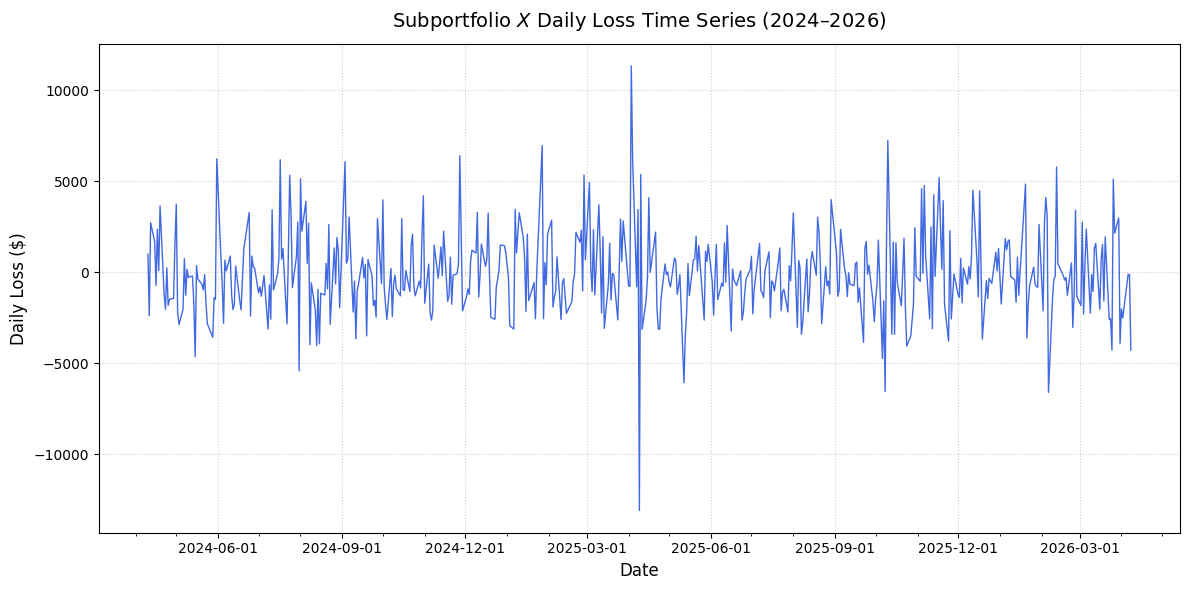

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Initialize Figure
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Plot Total Daily Loss Time Series
ax.plot(X.index, X.values, color='royalblue', linewidth=1, label='Portfolio Daily Loss ($X$)')

# 3. Format the Horizontal Axis (Dates)
# Set major ticks to show at the start of every quarter
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
# Format labels as Year-Month (e.g., 2024-04)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Optional: Format minor ticks for months
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Rotate date labels slightly to prevent crowding
plt.xticks(rotation=0)

# 4. Styling and Labels
ax.set_title('Subportfolio $X$ Daily Loss Time Series (2024–2026)', fontsize=14, pad=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Loss ($)', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
# ax.legend(loc='upper left', frameon=True)

# Adjust layout and display
plt.tight_layout()
plt.show()

Recall that the most precisely localized structural break date is April 9, 2025. From the time series graph, we see that this date is close to April 1, 2025 and there was a mean level change near that date. Furthermore, April 9, 2025 was one the dates listed as possible structural break dates by the economists at TD Bank Group (https://economics.td.com/ca-trump-reciprocal-tariffs-2025). Therefore, April 9, 2025 is the actual structural break date of the regime shift (Trump's global tariffs 2025-2026).